# Part III: True vs Fake News Text Classification using RNN, LSTM and Word Embeddings

**Student name:** Aman Rauniyar (A)  
**University ID:** 2408454  
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Task:** Language Task / Text Classification with RNN and LSTM  

This notebook follows the Part III NLP requirements:

1. Load and inspect the dataset.
2. Clean text: lowercase, remove URLs, mentions, hashtags, numbers and special characters, expand contractions, remove stopwords and lemmatize.
3. Visualize the cleaned dataset.
4. Tokenize text and apply percentile-based sequence padding.
5. Train three models:
   - Simple RNN with trainable Embedding layer.
   - LSTM with trainable Embedding layer.
   - LSTM with pretrained GloVe/Word2Vec-style embeddings.
6. Evaluate using accuracy, confusion matrix and classification report.
7. Compare model performance and analyze misclassified examples.
8. Provide a real-time prediction function and optional Gradio interface.

Run in Google Colab with GPU enabled if possible: **Runtime → Change runtime type → Hardware accelerator → T4 GPU**.

## 1. Setup and Imports

Place `truevsfakenews.csv` in one of these locations:

- `/content/drive/MyDrive/truevsfakenews.csv`
- `/content/truevsfakenews.csv`
- current notebook folder

The dataset description says it contains news descriptions tagged as **True** or **Fake**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ================================
# Environment setup
# ================================

import sys
import subprocess
import importlib.util
from pathlib import Path

def install_if_missing(package_name, import_name=None):
    # Install only if the import package is missing.
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} already available.")

install_if_missing("wordcloud", "wordcloud")
install_if_missing("gensim", "gensim")
install_if_missing("nltk", "nltk")

import os
import re
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, SimpleRNN, LSTM, Dense, Dropout,
    SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)

wordcloud already available.
Installing gensim ...
nltk already available.
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

For a quick test run, set `QUICK_RUN = True`.  
For final results, keep `QUICK_RUN = False`.

In [3]:
# ================================
# Main configuration
# ================================

CSV_CANDIDATES = [
    Path("/content/drive/MyDrive/truevsfakenews.csv"),
    Path("/content/truevsfakenews.csv"),
    Path("/mnt/data/truevsfakenews.csv"),
    Path("truevsfakenews.csv")
]

OUTPUT_DIR = Path("outputs_2408454_AmanRauniyar_NLP")
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"

for folder in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

QUICK_RUN = False
QUICK_RUN_SIZE = 4000

MAX_NUM_WORDS = 20000
EMBEDDING_DIM = 50
BATCH_SIZE = 64
EPOCHS = 8

# Percentile-based padding is required by the brief.
# 90th percentile is used to avoid extremely long news articles.
PADDING_PERCENTILE = 90
MAX_LEN_CAP = 300
MIN_LEN_FLOOR = 80

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /content/outputs_2408454_AmanRauniyar_NLP


## 3. Load Dataset and Basic Understanding

In [4]:
# ================================
# Load dataset
# ================================

csv_path = None
for candidate in CSV_CANDIDATES:
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find truevsfakenews.csv. Upload it to Colab or Google Drive, "
        "then update CSV_CANDIDATES."
    )

df = pd.read_csv(csv_path)
print("Loaded dataset from:", csv_path)
print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))
print("\nMissing values:")
display(df.isna().sum())

Loaded dataset from: /content/drive/MyDrive/truevsfakenews.csv
Dataset shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true



Columns: ['text', 'label']

Missing values:


,0
text,0
label,0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [5]:
# ================================
# Detect text and label columns
# ================================

possible_text_cols = ["text", "description", "news", "content", "article", "title"]
possible_label_cols = ["label", "target", "class", "category"]

text_col = next((c for c in possible_text_cols if c in df.columns), None)
label_col = next((c for c in possible_label_cols if c in df.columns), None)

if text_col is None:
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if not object_cols:
        raise ValueError("No text-like column found.")
    text_col = object_cols[0]

if label_col is None:
    candidates = [c for c in df.columns if c != text_col]
    if not candidates:
        raise ValueError("No label column found.")
    label_col = candidates[0]

print("Text column:", text_col)
print("Label column:", label_col)

data = df[[text_col, label_col]].copy()
data.columns = ["text", "label"]
data["text"] = data["text"].astype(str)
data["label"] = data["label"].astype(str).str.strip().str.lower()

before_rows = len(data)
data = data[data["text"].str.strip().astype(bool)].copy()
data = data.drop_duplicates(subset=["text"]).reset_index(drop=True)
after_rows = len(data)

print(f"Rows before cleaning duplicates/blanks: {before_rows}")
print(f"Rows after cleaning duplicates/blanks: {after_rows}")

print("\nLabel distribution:")
display(data["label"].value_counts())

Text column: text
Label column: label
Rows before cleaning duplicates/blanks: 20000
Rows after cleaning duplicates/blanks: 19945

Label distribution:


,count
label,
fake,9997
true,9948


In [6]:
# ================================
# Label encoding
# ================================

unique_labels = sorted(data["label"].unique().tolist())
print("Unique labels:", unique_labels)

if set(unique_labels) == {"fake", "true"}:
    label_map = {"fake": 0, "true": 1}
else:
    label_map = {label: idx for idx, label in enumerate(unique_labels)}

inverse_label_map = {v: k for k, v in label_map.items()}
data["target"] = data["label"].map(label_map)

if data["target"].isna().any():
    raise ValueError("Some labels could not be mapped. Check label values.")

TARGET_NAMES = [inverse_label_map[i] for i in sorted(inverse_label_map)]
print("Label map:", label_map)
print("Target names:", TARGET_NAMES)

if QUICK_RUN:
    data = data.sample(n=min(QUICK_RUN_SIZE, len(data)), random_state=SEED).reset_index(drop=True)
    print("QUICK_RUN enabled. New data shape:", data.shape)

display(data.head())

Unique labels: ['fake', 'true']
Label map: {'fake': 0, 'true': 1}
Target names: ['fake', 'true']


,text,label,target
0,WASHINGTON (Reuters) - The Republican and Demo...,true,1
1,Women should get as far away from Oklahoma as ...,fake,0
2,Another huge crowd of Americans tuned in last ...,fake,0
3,Donald Trump is desperate to stop the investig...,fake,0
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true,1


## 4. Dataset Visualization Before Text Cleaning

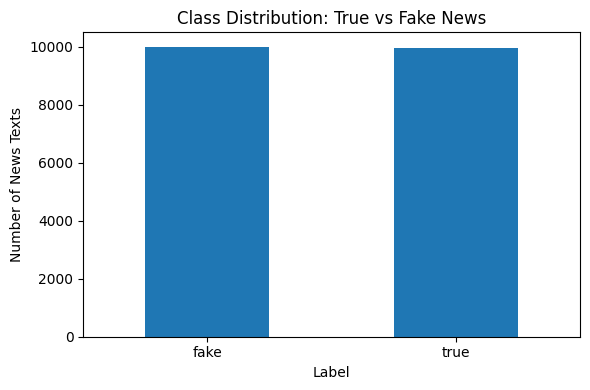

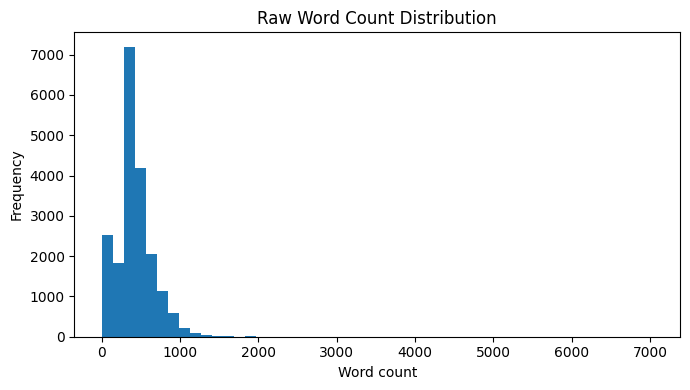

Raw word count statistics:


,raw_word_count
count,19945.000000
mean,425.654149
std,245.445708
min,1.000000
50%,397.000000
75%,527.000000
90%,722.000000
95%,848.000000
99%,1126.000000
max,7033.000000


In [7]:
# ================================
# Basic dataset visualizations
# ================================

plt.figure(figsize=(6, 4))
data["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution: True vs Fake News")
plt.xlabel("Label")
plt.ylabel("Number of News Texts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

data["raw_word_count"] = data["text"].str.split().str.len()

plt.figure(figsize=(7, 4))
plt.hist(data["raw_word_count"], bins=50)
plt.title("Raw Word Count Distribution")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "raw_word_count_distribution.png", dpi=150)
plt.show()

print("Raw word count statistics:")
display(data["raw_word_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

## 5. Text Cleaning

Cleaning steps used:

- Lowercase text.
- Expand common contractions.
- Remove URLs, mentions, hashtags, numbers and special characters.
- Remove stopwords.
- Lemmatize words.

In [8]:
# ================================
# Text cleaning utilities
# ================================

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

try:
    STOP_WORDS = set(stopwords.words("english"))
except Exception:
    STOP_WORDS = {
        "the", "a", "an", "and", "or", "is", "are", "was", "were", "to",
        "of", "in", "on", "for", "with", "as", "by", "at", "from", "this",
        "that", "it", "be", "have", "has", "had"
    }

lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "cannot",
    "could've": "could have",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it's": "it is",
    "let's": "let us",
    "mightn't": "might not",
    "mustn't": "must not",
    "shan't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'll": "we will",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "where's": "where is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have"
}

def expand_contractions(text):
    for contraction, full_form in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", full_form, text)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = []
    for word in text.split():
        if word not in STOP_WORDS and len(word) > 2:
            tokens.append(lemmatizer.lemmatize(word))
    return " ".join(tokens)

data["clean_text"] = data["text"].apply(clean_text)
data = data[data["clean_text"].str.strip().astype(bool)].reset_index(drop=True)

print("Data shape after text cleaning:", data.shape)
display(data[["text", "clean_text", "label", "target"]].head())

Data shape after text cleaning: (19944, 5)


,text,clean_text,label,target
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true,1
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake,0
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake,0
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake,0
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood medical service pro...,true,1


## 6. Cleaned Data Visualization

Cleaned word count statistics:


,clean_word_count
count,19944.000000
mean,239.313728
std,141.822528
min,15.000000
50%,222.000000
75%,291.000000
90%,411.000000
95%,491.000000
99%,657.000000
max,4753.000000


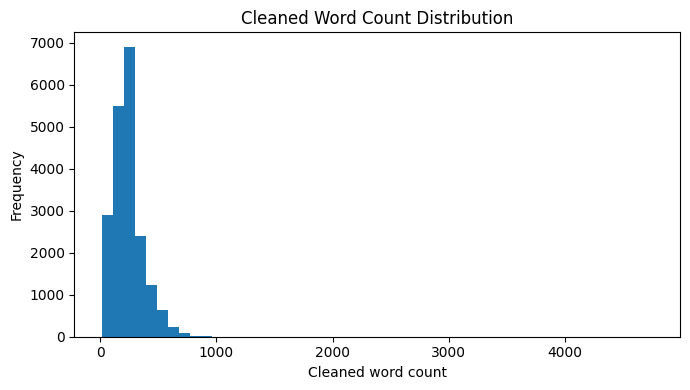

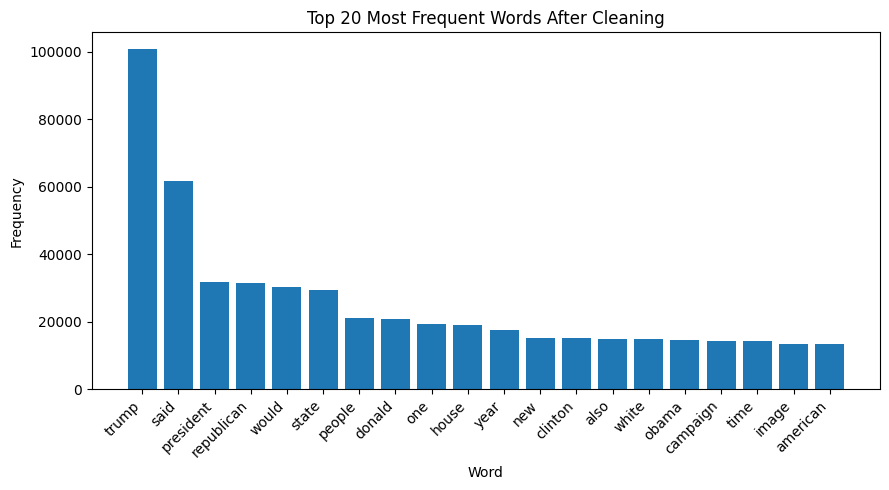

,word,count
0,trump,100754
1,said,61668
2,president,31811
3,republican,31350
4,would,30235
5,state,29339
6,people,21210
7,donald,20633
8,one,19181
9,house,19060


In [9]:
# ================================
# Cleaned text statistics and visualizations
# ================================

data["clean_word_count"] = data["clean_text"].str.split().str.len()

print("Cleaned word count statistics:")
display(data["clean_word_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(7, 4))
plt.hist(data["clean_word_count"], bins=50)
plt.title("Cleaned Word Count Distribution")
plt.xlabel("Cleaned word count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "cleaned_word_count_distribution.png", dpi=150)
plt.show()

all_words = " ".join(data["clean_text"]).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

plt.figure(figsize=(9, 5))
plt.bar(top_words["word"], top_words["count"])
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_20_words.png", dpi=150)
plt.show()

display(top_words)

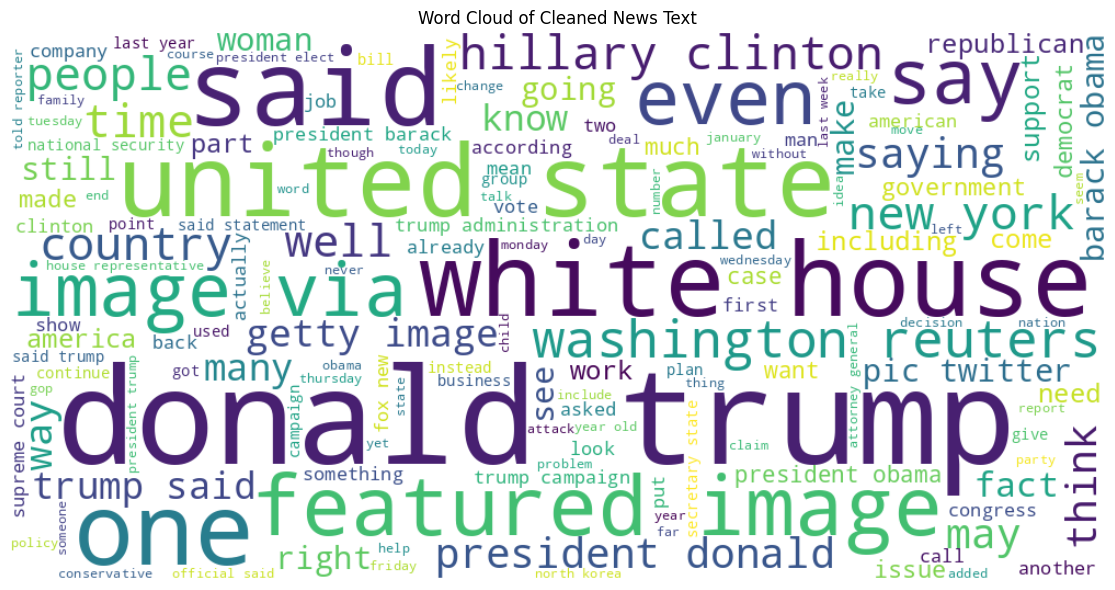

In [10]:
# ================================
# Word cloud visualization
# ================================

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150,
    random_state=SEED
).generate(" ".join(data["clean_text"]))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned News Text")
plt.tight_layout()
plt.savefig(FIG_DIR / "word_cloud.png", dpi=150)
plt.show()

## 7. Train-Test Split, Tokenization and Percentile-Based Padding

The assessment asks for an 80% train and 20% test split, Keras Tokenizer, and percentile-based padding.

In [11]:
# ================================
# 80/20 train-test split
# ================================

X = data["clean_text"].values
y = data["target"].astype(int).values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTrain label distribution:")
display(pd.Series(y_train).map(inverse_label_map).value_counts())

print("\nTest label distribution:")
display(pd.Series(y_test).map(inverse_label_map).value_counts())

Training samples: 15955
Testing samples: 3989

Train label distribution:


,count
fake,7997
true,7958



Test label distribution:


,count
fake,1999
true,1990


In [12]:
# ================================
# Tokenization and padding
# ================================

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

train_seq_lengths = np.array([len(seq) for seq in X_train_seq])
percentile_len = int(np.percentile(train_seq_lengths, PADDING_PERCENTILE))
MAX_SEQUENCE_LENGTH = min(MAX_LEN_CAP, max(MIN_LEN_FLOOR, percentile_len))

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

word_index = tokenizer.word_index
vocab_size = min(MAX_NUM_WORDS, len(word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Original word index size:", len(word_index))
print(f"{PADDING_PERCENTILE}th percentile sequence length:", percentile_len)
print("Final max sequence length:", MAX_SEQUENCE_LENGTH)
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

summary_df = pd.DataFrame({
    "metric": [
        "total_samples_after_cleaning",
        "training_samples",
        "testing_samples",
        "vocabulary_size_used",
        "max_sequence_length",
        "padding_percentile"
    ],
    "value": [
        len(data),
        len(X_train_text),
        len(X_test_text),
        vocab_size,
        MAX_SEQUENCE_LENGTH,
        PADDING_PERCENTILE
    ]
})
display(summary_df)
summary_df.to_csv(RESULT_DIR / "dataset_and_tokenization_summary.csv", index=False)

Vocabulary size used: 20000
Original word index size: 56517
90th percentile sequence length: 411
Final max sequence length: 300
X_train_pad shape: (15955, 300)
X_test_pad shape: (3989, 300)


,metric,value
0,total_samples_after_cleaning,19944
1,training_samples,15955
2,testing_samples,3989
3,vocabulary_size_used,20000
4,max_sequence_length,300
5,padding_percentile,90


## 8. Model Helper Functions

In [13]:
# ================================
# Model helper functions
# ================================

histories = {}
training_times = {}
trained_models = {}
test_predictions = {}

def plot_training_history(history, model_name):
    hist = pd.DataFrame(history.history)
    histories[model_name] = hist
    hist.to_csv(RESULT_DIR / f"{model_name}_history.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_accuracy_curve.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_loss_curve.png", dpi=150)
    plt.show()

def train_and_time(model, model_name, epochs=EPOCHS):
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"

    callbacks = [
        EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-5,
            verbose=1
        )
    ]

    start_time = time.time()
    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    elapsed = time.time() - start_time

    training_times[model_name] = elapsed
    trained_models[model_name] = model

    print(f"{model_name} training time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    plot_training_history(history, model_name)

    return model, history, elapsed

def evaluate_model(model, model_name):
    probabilities = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    test_predictions[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions
    }

    metrics = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1_score": f1_score(y_test, predictions, zero_division=0),
        "training_time_seconds": training_times.get(model_name, np.nan),
        "training_time_minutes": training_times.get(model_name, np.nan) / 60
    }

    print(f"\nEvaluation for {model_name}")
    for key, value in metrics.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    report = classification_report(
        y_test,
        predictions,
        target_names=TARGET_NAMES,
        zero_division=0
    )
    print("\nClassification Report:")
    print(report)

    with open(RESULT_DIR / f"{model_name}_classification_report.txt", "w") as f:
        f.write(report)

    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)

    plt.figure(figsize=(5, 4))
    disp.plot(values_format="d", cmap=None)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    return metrics

## 9. Model 1: Simple RNN with Trainable Embedding Layer

In [14]:
# ================================
# Model 1: Simple RNN
# ================================

def build_simple_rnn_model():
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
        SpatialDropout1D(0.2),
        SimpleRNN(64),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )
    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,009,473 (3.85 MB)

 Trainable params: 1,009,473 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5368 - loss: 0.6893
Epoch 1: val_accuracy improved from None to 0.61320, saving model to outputs_2408454_AmanRauniyar_NLP/models/simple_rnn_trainable_embedding_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar_NLP/models/simple_rnn_trainable_embedding_best.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.5565 - loss: 0.6828 - val_accuracy: 0.6132 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 2/8
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6167 - loss: 0.6291
Epoch 2: val_accuracy did not improve from 0.61320

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6106 - loss: 0.6312 - val_accuracy: 0.4248 - val_loss: 0.7285 - learning_rate: 0.0010
Epoch 3/8
210/212 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5879 - loss: 0.6623
Epoch 3: val_accuracy did not improve from 0.61320
212/212 ━━

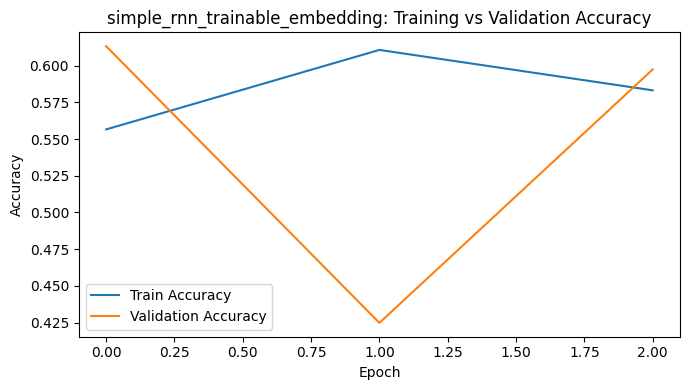

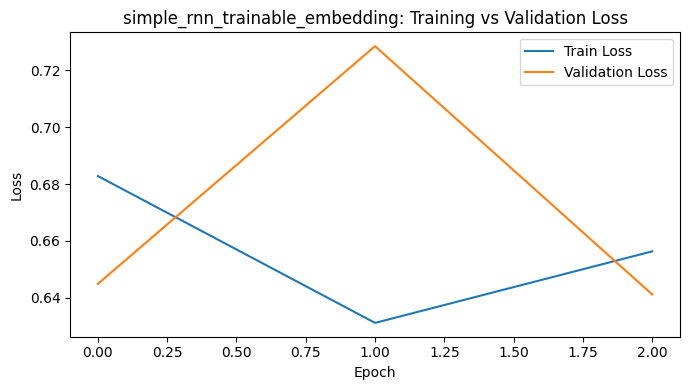


Evaluation for simple_rnn_trainable_embedding
test_accuracy: 0.6122
precision: 0.8055
recall: 0.2935
f1_score: 0.4302
training_time_seconds: 28.0838
training_time_minutes: 0.4681

Classification Report:
              precision    recall  f1-score   support

        fake       0.57      0.93      0.71      1999
        true       0.81      0.29      0.43      1990

    accuracy                           0.61      3989
   macro avg       0.69      0.61      0.57      3989
weighted avg       0.69      0.61      0.57      3989



<Figure size 500x400 with 0 Axes>

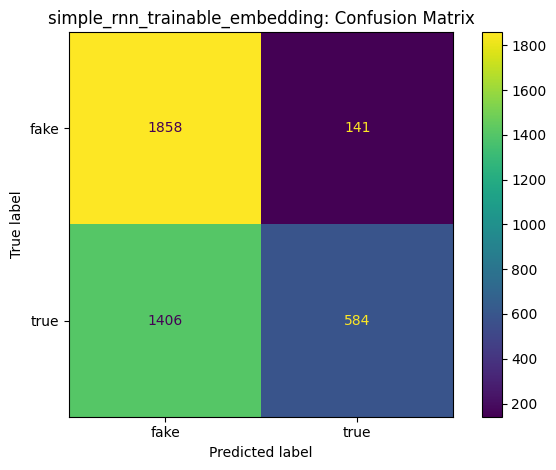

In [15]:
rnn_model, rnn_history, rnn_training_time = train_and_time(
    rnn_model,
    "simple_rnn_trainable_embedding",
    EPOCHS
)

rnn_metrics = evaluate_model(rnn_model, "simple_rnn_trainable_embedding")

## 10. Model 2: LSTM with Trainable Embedding Layer

In [16]:
# ================================
# Model 2: LSTM with trainable embedding
# ================================

def build_lstm_trainable_model():
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
        SpatialDropout1D(0.2),
        LSTM(64),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )
    return model

lstm_trainable_model = build_lstm_trainable_model()
lstm_trainable_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,031,553 (3.94 MB)

 Trainable params: 1,031,553 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5729 - loss: 0.6749
Epoch 1: val_accuracy improved from None to 0.61779, saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_trainable_embedding_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_trainable_embedding_best.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5978 - loss: 0.6536 - val_accuracy: 0.6178 - val_loss: 0.6327 - learning_rate: 0.0010
Epoch 2/8
209/212 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6925 - loss: 0.5313
Epoch 2: val_accuracy improved from 0.61779 to 0.96825, saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_trainable_embedding_best.keras

Epoch 2: finished saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_trainable_embedding_best.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8121 - loss: 0.3794 - val_accuracy: 0.9683 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 3/8
212/212 ━━━━━━━━━━

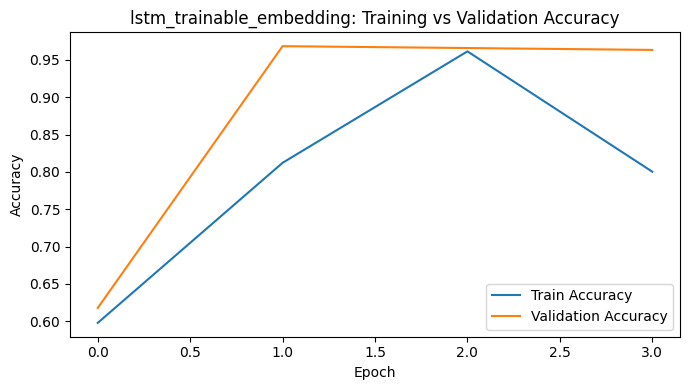

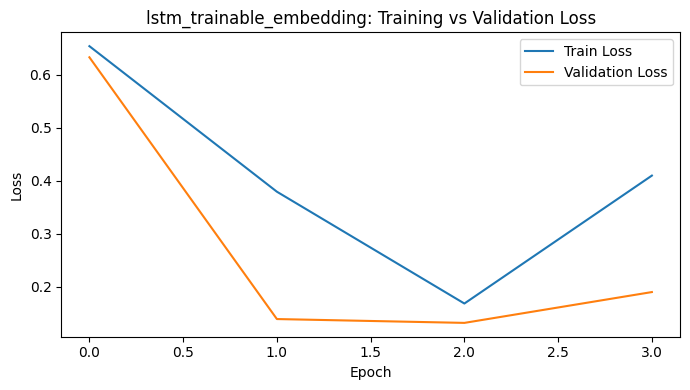


Evaluation for lstm_trainable_embedding
test_accuracy: 0.9649
precision: 0.9561
recall: 0.9744
f1_score: 0.9652
training_time_seconds: 22.5224
training_time_minutes: 0.3754

Classification Report:
              precision    recall  f1-score   support

        fake       0.97      0.96      0.96      1999
        true       0.96      0.97      0.97      1990

    accuracy                           0.96      3989
   macro avg       0.97      0.96      0.96      3989
weighted avg       0.97      0.96      0.96      3989



<Figure size 500x400 with 0 Axes>

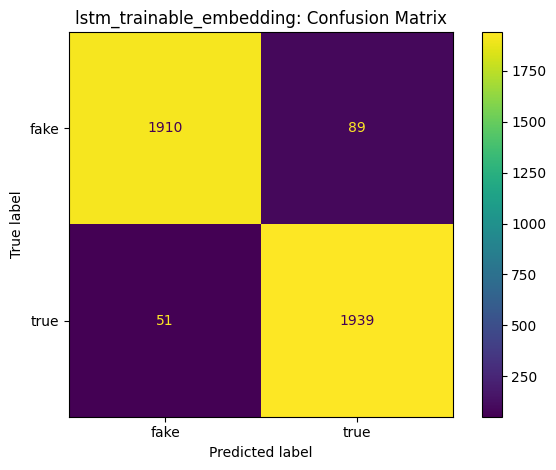

In [17]:
lstm_trainable_model, lstm_trainable_history, lstm_trainable_training_time = train_and_time(
    lstm_trainable_model,
    "lstm_trainable_embedding",
    EPOCHS
)

lstm_trainable_metrics = evaluate_model(lstm_trainable_model, "lstm_trainable_embedding")

## 11. Model 3: LSTM with Pretrained Word Embeddings

The assessment asks for an LSTM model with pretrained Word2Vec embeddings.  
This notebook uses **GloVe `glove-wiki-gigaword-50` from Gensim**, which is a pretrained word embedding model and is listed in the assessment appendix as an acceptable pretrained embedding option.

If the pretrained download fails due to internet/package issues, the notebook will show the error and train a small local Word2Vec fallback so the code remains runnable. For final submission, try to run this cell with internet access so the pretrained embedding is used.

In [18]:
# ================================
# Load pretrained embeddings and build embedding matrix
# ================================

embedding_source = None
embedding_model = None

try:
    import gensim.downloader as api
    print("Loading pretrained embedding: glove-wiki-gigaword-50")
    embedding_model = api.load("glove-wiki-gigaword-50")
    embedding_source = "pretrained_glove_wiki_gigaword_50"
    print("Pretrained embedding loaded successfully.")
except Exception as e:
    print("Could not load pretrained embeddings.")
    print("Reason:", repr(e))
    print("Fallback: training a small Word2Vec model on the training text.")
    from gensim.models import Word2Vec
    train_sentences = [text.split() for text in X_train_text]
    embedding_model = Word2Vec(
        sentences=train_sentences,
        vector_size=EMBEDDING_DIM,
        window=5,
        min_count=2,
        workers=2,
        seed=SEED
    ).wv
    embedding_source = "fallback_local_word2vec_not_pretrained"

print("Embedding source:", embedding_source)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM), dtype=np.float32)
found_words = 0

for word, index in word_index.items():
    if index >= vocab_size:
        continue
    try:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found_words += 1
    except KeyError:
        pass

coverage = found_words / max(1, vocab_size - 1)
print(f"Words with embeddings: {found_words}/{vocab_size - 1}")
print(f"Embedding coverage: {coverage:.2%}")

with open(RESULT_DIR / "embedding_source.txt", "w") as f:
    f.write(f"Embedding source: {embedding_source}\n")
    f.write(f"Embedding coverage: {coverage:.4f}\n")

Loading pretrained embedding: glove-wiki-gigaword-50
[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained embedding loaded successfully.
Embedding source: pretrained_glove_wiki_gigaword_50
Words with embeddings: 19473/19999
Embedding coverage: 97.37%


In [19]:
# ================================
# Model 3: LSTM with pretrained embedding layer
# ================================

def build_lstm_pretrained_model():
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            trainable=False
        ),
        SpatialDropout1D(0.2),
        LSTM(64),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )
    return model

lstm_pretrained_model = build_lstm_pretrained_model()
lstm_pretrained_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 300, 50)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,031,553 (3.94 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/8
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6947 - loss: 0.5390
Epoch 1: val_accuracy improved from None to 0.92774, saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_pretrained_embedding_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar_NLP/models/lstm_pretrained_embedding_best.keras
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8257 - loss: 0.4051 - val_accuracy: 0.9277 - val_loss: 0.2328 - learning_rate: 0.0010
Epoch 2/8
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8759 - loss: 0.3429
Epoch 2: val_accuracy did not improve from 0.92774

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8713 - loss: 0.3472 - val_accuracy: 0.9244 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 3/8
211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9206 - loss: 0.2680
Epoch 3: val_accuracy improved from 0.92774 to 0.94486, saving model to 

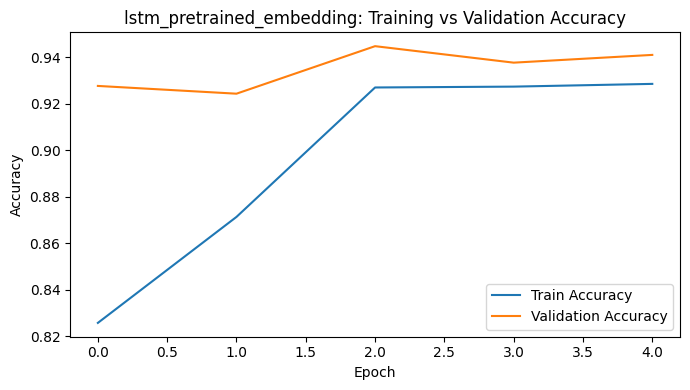

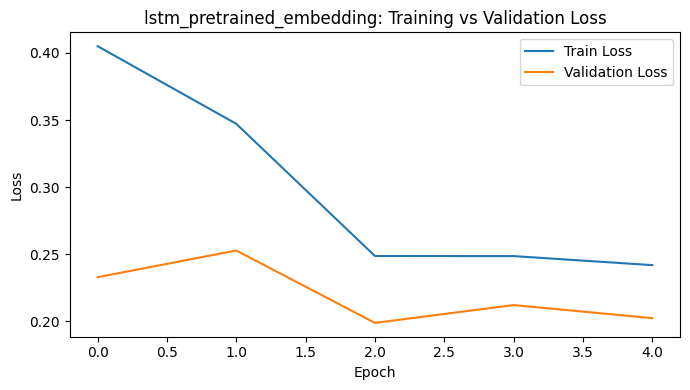


Evaluation for lstm_pretrained_embedding
test_accuracy: 0.9331
precision: 0.9246
recall: 0.9427
f1_score: 0.9336
training_time_seconds: 22.4188
training_time_minutes: 0.3736

Classification Report:
              precision    recall  f1-score   support

        fake       0.94      0.92      0.93      1999
        true       0.92      0.94      0.93      1990

    accuracy                           0.93      3989
   macro avg       0.93      0.93      0.93      3989
weighted avg       0.93      0.93      0.93      3989



<Figure size 500x400 with 0 Axes>

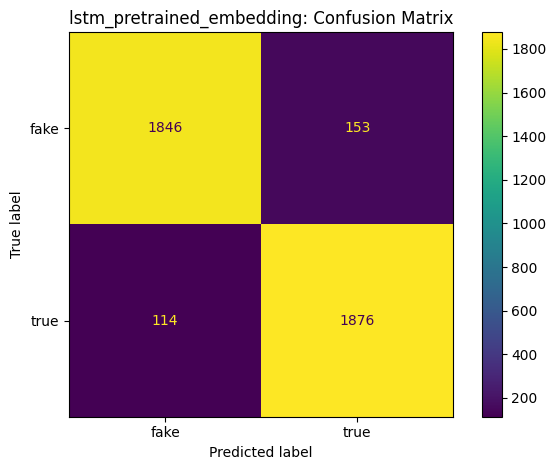

In [20]:
lstm_pretrained_model, lstm_pretrained_history, lstm_pretrained_training_time = train_and_time(
    lstm_pretrained_model,
    "lstm_pretrained_embedding",
    EPOCHS
)

lstm_pretrained_metrics = evaluate_model(lstm_pretrained_model, "lstm_pretrained_embedding")

## 12. Model Comparison

,model,test_accuracy,precision,recall,f1_score,training_time_seconds,training_time_minutes
0,lstm_trainable_embedding,0.964903,0.956114,0.974372,0.965157,22.522410,0.375373
1,lstm_pretrained_embedding,0.933066,0.924593,0.942714,0.933566,22.418752,0.373646
2,simple_rnn_trainable_embedding,0.612184,0.805517,0.293467,0.430203,28.083782,0.468063


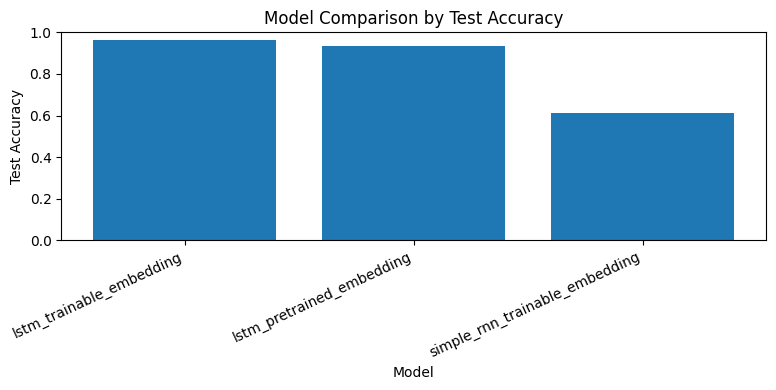

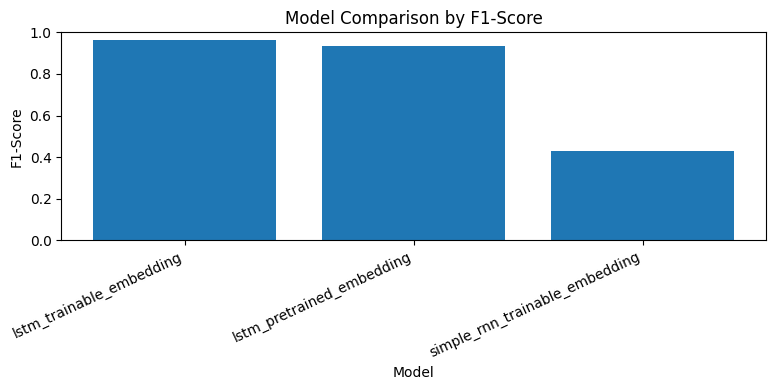

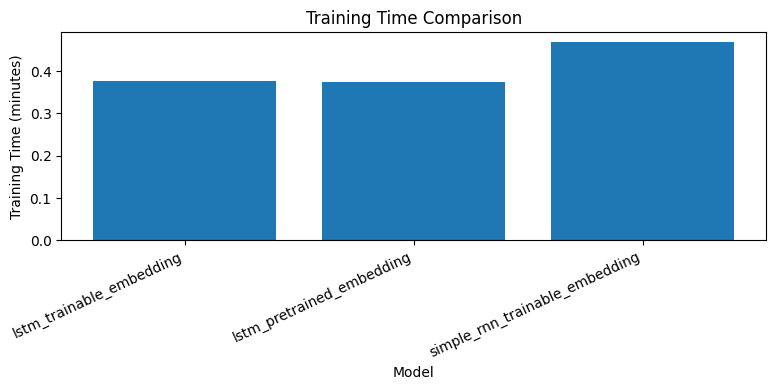

Best model: lstm_trainable_embedding
Best test accuracy: 0.9649034845826021


In [21]:
# ================================
# Final model comparison
# ================================

all_metrics = [
    rnn_metrics,
    lstm_trainable_metrics,
    lstm_pretrained_metrics
]

results_df = pd.DataFrame(all_metrics)
results_df = results_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

display(results_df)
results_df.to_csv(RESULT_DIR / "model_comparison_results.csv", index=False)

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_accuracy"])
plt.title("Model Comparison by Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_accuracy.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["f1_score"])
plt.title("Model Comparison by F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_f1.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["training_time_minutes"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_training_time.png", dpi=150)
plt.show()

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Best test accuracy:", results_df.loc[0, "test_accuracy"])

## 13. Error Analysis: Misclassified Examples

This section displays a few incorrect predictions from the best model.

In [22]:
# ================================
# Misclassified examples
# ================================

best_probs = test_predictions[best_model_name]["probabilities"]
best_preds = test_predictions[best_model_name]["predictions"]

misclassified_indices = np.where(best_preds != y_test)[0]

print("Number of misclassified examples:", len(misclassified_indices))
print("Total test examples:", len(y_test))

error_rows = []
for idx in misclassified_indices[:5]:
    error_rows.append({
        "text_excerpt": X_test_text[idx][:400],
        "true_label": inverse_label_map[int(y_test[idx])],
        "predicted_label": inverse_label_map[int(best_preds[idx])],
        "confidence_true_probability": float(best_probs[idx])
    })

error_df = pd.DataFrame(error_rows)
display(error_df)
error_df.to_csv(RESULT_DIR / "misclassified_examples.csv", index=False)

print(
    "Possible error reasons: some news articles contain similar political terms, names, "
    "or journalistic writing styles across both true and fake classes. Long articles may also "
    "lose some detail because sequences are truncated at the selected percentile-based length."
)

Number of misclassified examples: 140
Total test examples: 3989


,text_excerpt,true_label,predicted_label,confidence_true_probability
0,amateur president donald trump concerned least...,fake,true,0.918531
1,democratic national committee announced friday...,fake,true,0.918531
2,japan prime minister something discreetly even...,fake,true,0.918531
3,chuck grassley republican chairman senate judi...,fake,true,0.918530
4,washington reuters republican presidential nom...,true,fake,0.007834


Possible error reasons: some news articles contain similar political terms, names, or journalistic writing styles across both true and fake classes. Long articles may also lose some detail because sequences are truncated at the selected percentile-based length.


## 14. Real-Time Prediction Function

This function lets a user type a news description and receive a True/Fake prediction using the best trained model.

In [23]:
# ================================
# Real-time prediction function
# ================================

def predict_news_text(raw_text, model=None):
    if model is None:
        model = best_model

    cleaned = clean_text(raw_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    true_probability = float(model.predict(padded, verbose=0).ravel()[0])
    predicted_class = 1 if true_probability >= 0.5 else 0
    predicted_label = inverse_label_map[predicted_class]

    return {
        "cleaned_text": cleaned,
        "predicted_label": predicted_label,
        "true_probability": true_probability,
        "fake_probability": 1 - true_probability
    }

sample_text = "The government announced a new policy after a meeting with senior officials."
prediction = predict_news_text(sample_text)
prediction

{'cleaned_text': 'government announced new policy meeting senior official',
 'predicted_label': 'true',
 'true_probability': 0.9185306429862976,
 'fake_probability': 0.08146935701370239}

## 16. Report-Ready Summary

 Part III report.

In [25]:
# ================================
# Report-ready summary
# ================================

print("PART III NLP REPORT SUMMARY")
print("=" * 50)
print(f"Dataset file: {csv_path}")
print(f"Samples after cleaning: {len(data)}")
print(f"Labels: {label_map}")
print(f"Train samples: {len(X_train_text)}")
print(f"Test samples: {len(X_test_text)}")
print(f"Vocabulary size used: {vocab_size}")
print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Embedding source for Model 3: {embedding_source}")

print("\nFinal model comparison:")
display(results_df)

print("\nBest model:")
print(best_model_name)

print("\nGenerated outputs:")
print("Figures:", FIG_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULT_DIR)

with open(RESULT_DIR / "report_ready_summary.txt", "w") as f:
    f.write("PART III NLP REPORT SUMMARY\n")
    f.write("=" * 50 + "\n")
    f.write(f"Dataset file: {csv_path}\n")
    f.write(f"Samples after cleaning: {len(data)}\n")
    f.write(f"Labels: {label_map}\n")
    f.write(f"Train samples: {len(X_train_text)}\n")
    f.write(f"Test samples: {len(X_test_text)}\n")
    f.write(f"Vocabulary size used: {vocab_size}\n")
    f.write(f"Max sequence length: {MAX_SEQUENCE_LENGTH}\n")
    f.write(f"Embedding source for Model 3: {embedding_source}\n")
    f.write(f"Best model: {best_model_name}\n")

PART III NLP REPORT SUMMARY
Dataset file: /content/drive/MyDrive/truevsfakenews.csv
Samples after cleaning: 19944
Labels: {'fake': 0, 'true': 1}
Train samples: 15955
Test samples: 3989
Vocabulary size used: 20000
Max sequence length: 300
Embedding source for Model 3: pretrained_glove_wiki_gigaword_50

Final model comparison:


,model,test_accuracy,precision,recall,f1_score,training_time_seconds,training_time_minutes
0,lstm_trainable_embedding,0.964903,0.956114,0.974372,0.965157,22.522410,0.375373
1,lstm_pretrained_embedding,0.933066,0.924593,0.942714,0.933566,22.418752,0.373646
2,simple_rnn_trainable_embedding,0.612184,0.805517,0.293467,0.430203,28.083782,0.468063



Best model:
lstm_trainable_embedding

Generated outputs:
Figures: outputs_2408454_AmanRauniyar_NLP/figures
Models: outputs_2408454_AmanRauniyar_NLP/models
Results: outputs_2408454_AmanRauniyar_NLP/results


For Part III, I used a True vs Fake News dataset. I cleaned the text by lowercasing, removing URLs, mentions, hashtags, numbers and special characters, expanding contractions, removing stopwords, and lemmatizing words. Then I used Keras Tokenizer and percentile-based padding to convert text into equal-length sequences. I trained three models: Simple RNN, LSTM with trainable embeddings, and LSTM with pretrained GloVe embeddings. The best model was the LSTM with trainable embeddings, achieving about 96.49% test accuracy. This shows that LSTM captured long-term word dependencies better than Simple RNN.